In [1]:
%load_ext autoreload
%autoreload 2

import torch
from ncpu.runner  import setup_scheduled_trainer
from ncpu.dataset import NCPUDataset

from matplotlib import pyplot as plt
from IPython.display import clear_output, display
from tqdm.auto import tqdm

model_path = None

In [2]:

from ncpu.config import TINY_AND_TRAINING_CONFIG, TINY_AND_CLOSE_TRAINING_CONFIG, TINY_AND_FARAWAY_TRAINING_CONFIG
configs = [
    TINY_AND_TRAINING_CONFIG, 
    TINY_AND_CLOSE_TRAINING_CONFIG, 
    TINY_AND_FARAWAY_TRAINING_CONFIG
]

STEPS = 2_500

In [3]:

trainer = setup_scheduled_trainer(
    configs, 
    steps = STEPS
)


Sanity check...
  forward: torch.Size([2, 16, 32, 32]) -> torch.Size([2, 11, 16, 32, 32])
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
  batch: 2
  dataloader: torch.Size([8, 32, 32]) -> torch.Size([8, 32, 32])
  first_state: torch.Size([8, 16, 32, 32])
  rollout: torch.Size([8, 11, 16, 32, 32])
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050c

loss=0.000255:  96%|#########6| 2400/2500 [16:52<00:45,  2.22it/s]

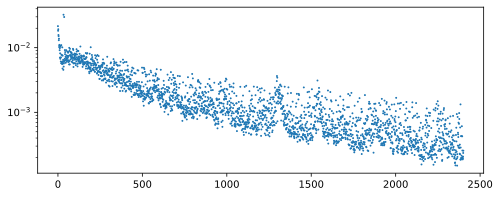

inp    : (8, 32, 32) torch.float32, min=0.00, max=1.03, mean=0.07, std=0.25
out    : (8, 32, 32) torch.float32, min=0.00, max=1.00, mean=0.03, std=0.16
nca_out: (8, 32, 32) torch.float32, min=-0.43, max=1.09, mean=0.04, std=0.18


,,,,,,,
,,,,,,,
,,,,,,,

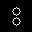
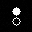
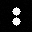
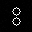
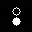
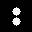
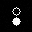
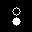
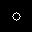
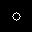
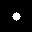
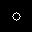
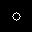
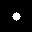
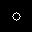
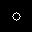
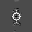
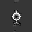
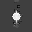
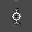
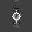
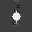
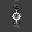
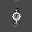

#0,#1,#2,#3,#4,#5,#6,#7

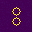
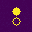
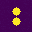
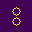
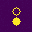
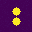
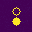
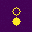

here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050c

In [4]:

stop_loss = 0.0001
pbar = tqdm(range(STEPS))
for i in pbar:
    info = trainer.optim_step(steps=(30, 80))
    loss = info["metrics"]["loss"]
    pbar.set_description(f"loss={loss:.6f}")

    if i % 100 == 0:
        clear_output(wait=False)
        display(pbar.container)

        trainer.display_optim_step(info)
        trainer.save_checkpoint()

    if loss == stop_loss:
        break

loss=0.000266:  84%|########4 | 2100/2500 [17:37<03:25,  1.95it/s]

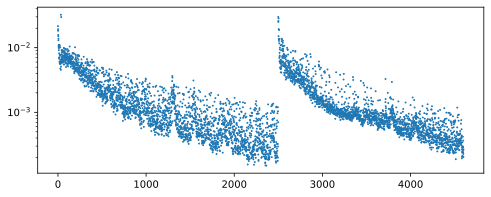

inp    : (8, 32, 32) torch.float32, min=0.00, max=1.03, mean=0.07, std=0.26
out    : (8, 32, 32) torch.float32, min=0.00, max=1.00, mean=0.03, std=0.17
nca_out: (8, 32, 32) torch.float32, min=-0.46, max=1.16, mean=0.04, std=0.19


,,,,,,,
,,,,,,,
,,,,,,,

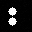
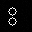
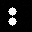
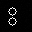
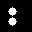
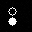
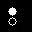
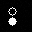
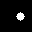
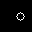
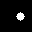
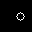
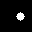
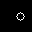
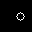
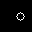
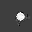
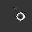
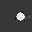
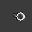
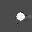
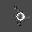
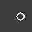
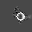

#0,#1,#2,#3,#4,#5,#6,#7

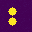
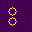
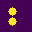
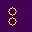
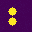
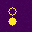
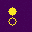
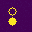

here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050cb7ba10>
here: <ncpu.dataset.ScheduledDataset object at 0x70050c

In [ ]:

stop_loss = 0.0001
pbar = tqdm(range(STEPS))
for i in pbar:
    info = trainer.optim_step(steps=(30, 80))
    loss = info["metrics"]["loss"]
    pbar.set_description(f"loss={loss:.6f}")

    if i % 100 == 0:
        clear_output(wait=False)
        display(pbar.container)

        trainer.display_optim_step(info)
        trainer.save_checkpoint()

    if loss == stop_loss:
        break

In [ ]:

stop_loss = 0.0001
pbar = tqdm(range(STEPS))
for i in pbar:
    info = trainer.optim_step(steps=(30, 80))
    loss = info["metrics"]["loss"]
    pbar.set_description(f"loss={loss:.6f}")

    if i % 100 == 0:
        clear_output(wait=False)
        display(pbar.container)

        trainer.display_optim_step(info)
        trainer.save_checkpoint()

    if loss == stop_loss:
        break